In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
data = pd.read_csv ('sales_data1.csv', encoding = 'latin1')
data.head(1)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ONLINE ORDERS,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30.0,95.7,2,2871.0,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small


In [5]:
data.shape

(2823, 25)

In [6]:
data.dtypes

ORDERNUMBER           int64
QUANTITYORDERED     float64
PRICEEACH           float64
ONLINE ORDERS         int64
SALES               float64
ORDERDATE               str
STATUS                  str
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE             str
MSRP                  int64
PRODUCTCODE             str
CUSTOMERNAME            str
PHONE                   str
ADDRESSLINE1            str
ADDRESSLINE2            str
CITY                    str
STATE                   str
POSTALCODE              str
COUNTRY                 str
TERRITORY               str
CONTACTLASTNAME         str
CONTACTFIRSTNAME        str
DEALSIZE                str
dtype: object

In [7]:
data.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        2
PRICEEACH              0
ONLINE ORDERS          0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [8]:
dataNAN = data.dropna()
dataNAN.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ONLINE ORDERS,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
10,10223,37.0,100.00,1,3965.66,2/20/2004 0:00,Shipped,1,2,2004,...,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium
21,10361,20.0,72.55,13,1451.00,12/17/2004 0:00,Shipped,4,12,2004,...,"Monitor Money Building, 815 Pacific Hwy",Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Small
40,10270,21.0,100.00,9,4905.39,7/19/2004 0:00,Shipped,3,7,2004,...,"Monitor Money Building, 815 Pacific Hwy",Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Medium
47,10347,30.0,100.00,1,3944.70,11/29/2004 0:00,Shipped,4,11,2004,...,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium
51,10391,24.0,100.00,4,2416.56,03/09/2005 00:00,Shipped,1,3,2005,...,201 Miller Street,Level 15,North Sydney,NSW,2060,Australia,APAC,O'Hara,Anna,Small


In [9]:
dataFill = dataNAN.fillna("")
print(dataFill)

      ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ONLINE ORDERS    SALES  \
10          10223             37.0     100.00              1  3965.66   
21          10361             20.0      72.55             13  1451.00   
40          10270             21.0     100.00              9  4905.39   
47          10347             30.0     100.00              1  3944.70   
51          10391             24.0     100.00              4  2416.56   
...           ...              ...        ...            ...      ...   
2667        10120             43.0      76.00             14  3268.00   
2673        10223             26.0      67.20             15  1747.20   
2685        10361             44.0     100.00             10  5001.92   
2764        10361             35.0     100.00             11  4277.35   
2791        10361             23.0      95.20             12  2189.60   

             ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
10      2/20/2004 0:00  Shipped       1         2     20

In [10]:
pd.options.display.float_format = '{:2}'.format
dataFill.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ONLINE ORDERS,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
10,10223,37.0,100.0,1,3965.66,2/20/2004 0:00,Shipped,1,2,2004,...,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium
21,10361,20.0,72.55,13,1451.0,12/17/2004 0:00,Shipped,4,12,2004,...,"Monitor Money Building, 815 Pacific Hwy",Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Small
40,10270,21.0,100.0,9,4905.39,7/19/2004 0:00,Shipped,3,7,2004,...,"Monitor Money Building, 815 Pacific Hwy",Level 6,Chatswood,NSW,2067,Australia,APAC,Huxley,Adrian,Medium
47,10347,30.0,100.0,1,3944.7,11/29/2004 0:00,Shipped,4,11,2004,...,636 St Kilda Road,Level 3,Melbourne,Victoria,3004,Australia,APAC,Ferguson,Peter,Medium
51,10391,24.0,100.0,4,2416.56,03/09/2005 00:00,Shipped,1,3,2005,...,201 Miller Street,Level 15,North Sydney,NSW,2060,Australia,APAC,O'Hara,Anna,Small


In [11]:
dataSplit = dataFill[["COUNTRY", "SALES", "QUANTITYORDERED"]]
dataSplit.head()

,COUNTRY,SALES,QUANTITYORDERED
10,Australia,3965.66,37.0
21,Australia,1451.0,20.0
40,Australia,4905.39,21.0
47,Australia,3944.7,30.0
51,Australia,2416.56,24.0


In [12]:
#Q4 
dataFill['SALES'] = dataFill['SALES'].astype(int)
dataFill["UNITSSOLD"] = dataFill["QUANTITYORDERED"] / dataFill["SALES"]
print(dataFill[['UNITSSOLD','QUANTITYORDERED','SALES']])

                UNITSSOLD  QUANTITYORDERED  SALES
10   0.009331651954602775             37.0   3965
21   0.013783597518952447             20.0   1451
40   0.004281345565749235             21.0   4905
47   0.007606490872210953             30.0   3944
51   0.009933774834437087             24.0   2416
...                   ...              ...    ...
2667 0.013157894736842105             43.0   3268
2673 0.014882655981682884             26.0   1747
2685 0.008798240351929614             44.0   5001
2764 0.008183306055646482             35.0   4277
2791 0.010507080858839652             23.0   2189

[147 rows x 3 columns]


In [13]:
#Q5. 
territory_data = dataFill.groupby(['TERRITORY']).sum().sort_values('UNITSSOLD', ascending = True)
territory_data[['QUANTITYORDERED','UNITSSOLD']].round()

,QUANTITYORDERED,UNITSSOLD
TERRITORY,,
APAC,4996.0,2.0


<Axes: >

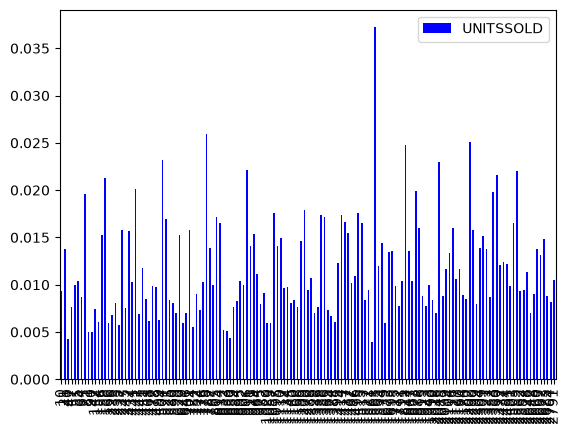

In [14]:
dataBar = dataFill[["TERRITORY","UNITSSOLD"]]
dataBar.plot(kind="bar",color= "blue")

In [15]:
#Q7.
grouped_data = dataFill.groupby(['COUNTRY', 'DEALSIZE'])[['SALES', 'UNITSSOLD']].sum()
grouped_data = grouped_data.sort_values('UNITSSOLD', ascending=False)
top_5_deal = grouped_data.nlargest(5, 'UNITSSOLD')
print(top_5_deal)

                     SALES           UNITSSOLD
COUNTRY   DEALSIZE                            
Australia Small     148288   1.091913161847153
          Medium    314395  0.6056775146376095
          Large      43808 0.02487216331442558


In [16]:
#Q8.
pivot_table = pd.pivot_table(
    dataFill,
    values='SALES',
    index=['COUNTRY','DEALSIZE'],
    aggfunc=[np.sum, np.mean]
)
print(pivot_table)

                       sum              mean
                     SALES             SALES
COUNTRY   DEALSIZE                          
Australia Large      43808            8761.6
          Medium    314395 4428.098591549296
          Small     148288  2088.56338028169


In [17]:
#Q9.
data.query('COUNTRY ==["France"]').groupby(["PRODUCTLINE"]).sum().sort_values('SALES', ascending= False)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ONLINE ORDERS,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
PRODUCTLINE,,,,,,,,,,,,,,,,,,,,,
Classic Cars,1003866,3540.0,8339.71,572,388951.2,11/25/2003 0:0010/11/2004 00:0011/08/2003 00:0...,ShippedShippedShippedShippedShippedShippedShip...,242,603,196369,...,"2, rue du Commerce67, avenue de l'Europe1 rue ...",,LyonVersaillesToulouseReimsParisParisLyonNante...,,6900478000310005110075508750126900444000130087...,FranceFranceFranceFranceFranceFranceFranceFran...,EMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEM...,SaveleyToniniRouletHenriotDa CunhaBertrandSave...,MaryDanielAnnettePaulDanielMarieMaryJanineLaur...,LargeLargeMediumSmallMediumMediumMediumMediumL...
Motorcycles,695940,2404.0,5478.94,448,226390.31,05/07/2003 00:0007/01/2003 00:0011/11/2003 00:...,ShippedShippedShippedShippedShippedShippedShip...,159,386,136257,...,59 rue de l'Abbaye27 rue du Colonel Pierre Avi...,,ReimsParisLilleParisNantesNantesParisLilleNant...,,5110075508590007501644000440007550859000440004...,FranceFranceFranceFranceFranceFranceFranceFran...,EMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEM...,HenriotDa CunhaRancePerrierLabruneLabruneDa Cu...,PaulDanielMartineDominiqueJanineJanineDanielMa...,SmallMediumSmallMediumMediumSmallMediumMediumS...
Vintage Cars,596789,1955.0,4431.13,406,176609.81,03/02/2004 00:0010/11/2004 00:0012/09/2004 00:...,ShippedShippedShippedShippedShippedShippedShip...,160,423,116234,...,"2, rue du Commerce67, avenue de l'Europe27 rue...",,LyonVersaillesParisLyonVersaillesParisLyonStra...,,6900478000755086900478000755086900467000130086...,FranceFranceFranceFranceFranceFranceFranceFran...,EMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEM...,SaveleyToniniDa CunhaSaveleyToniniDa CunhaSave...,MaryDanielDanielMaryDanielDanielMaryFrederique...,SmallMediumSmallSmallSmallSmallMediumLargeLarg...
Trucks and Buses,308355,1067.0,2690.62,161,116982.22,11/25/2003 0:0002/02/2004 00:0010/11/2004 00:0...,ShippedShippedShippedShippedIn ProcessShippedS...,86,222,60116,...,"2, rue du Commerce67, avenue de l'Europe67, av...",,LyonVersaillesVersaillesParisNantesLyonVersail...,,6900478000780007501244000690047800075012440007...,FranceFranceFranceFranceFranceFranceFranceFran...,EMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEM...,SaveleyToniniToniniBertrandLabruneSaveleyTonin...,MaryDanielDanielMarieJanineMaryDanielMarieJani...,MediumMediumMediumMediumMediumSmallMediumMediu...
Planes,330194,1136.0,2630.92,277,108155.51000000001,11/08/2003 00:003/30/2005 0:007/23/2004 0:003/...,ShippedShippedShippedShippedShippedShippedShip...,68,175,64139,...,"1 rue Alsace-Lorraine59 rue de l'Abbaye67, rue...",,ToulouseReimsNantesReimsNantesReimsToulouseRei...,,3100051100440005110044000511003100051100310004...,FranceFranceFranceFranceFranceFranceFranceFran...,EMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEM...,RouletHenriotLabruneHenriotLabruneHenriotRoule...,AnnettePaulJaninePaulJaninePaulAnnettePaulAnne...,MediumMediumMediumSmallSmallMediumSmallSmallSm...
Ships,216168,766.0,1734.3,114,66486.67,11/08/2003 00:003/30/2005 0:0001/02/2004 00:00...,ShippedShippedShippedShippedShippedShippedShip...,42,100,42089,...,"1 rue Alsace-Lorraine59 rue de l'Abbaye2, rue ...",,ToulouseReimsLyonNantesLyonNantesLyonToulouseT...,,3100051100690044400069004440006900431000310005...,FranceFranceFranceFranceFranceFranceFranceFran...,EMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEMEAEM...,RouletHenriotSaveleyLabruneSaveleyLabruneSavel...,AnnettePaulMaryJanineMaryJanineMaryAnnetteAnne...,MediumSmallMediumMediumSmallSmallMediumSmallMe...
Trains,72201,222.0,615.25,50,27340.8,01/02/2004 00:0011/20/2004 0:0011/20/2004 0:00...,ShippedShippedShippedShippedShippedShippedShipped,19,51,14029,...,"2, rue du Commerce265, boulevard Charonne265, ...",,LyonParisParisReimsLyonReimsParis,,69004750127501251100690045110075508,FranceFranceFranceFranceFranceFranceFrance,EMEAEMEAEMEAEME

In [ ]:
Question 10. #To change the order date. 
data['Order Date'] = pd.to_datetime(data['Order Date'], dayfirst= True)

#To change date to Irish date format.
#data['Order Date'] = data['Order Date'].dt.strftime('%d/%m/%Y')

#to extract year from the Order date column.
data['Year'] = data['Order Date'].dt.year.astype('Int64')

In [18]:
#Q10. 
data.loc[(data['YEAR_ID'] == 2003),['COUNTRY','SALES','PRODUCTLINE']]

,COUNTRY,SALES,PRODUCTLINE
0,USA,2871.0,Motorcycles
1,France,2765.9,Motorcycles
2,France,3884.34,Motorcycles
3,USA,3746.7,Motorcycles
4,USA,5205.27,Motorcycles
...,...,...,...
2801,Spain,3003.0,Ships
2802,Sweden,1846.42,Ships
2803,Spain,2009.2,Ships
2804,USA,1804.04,Ships


In [19]:
#Q11. 
 data.loc[(data['TERRITORY'] == 'EMEA') & (data['STATUS'] == 'Shipped') & (data['QUANTITYORDERED'] > 50),['COUNTRY','PRODUCTLINE','SALES','YEAR_ID']]  

,COUNTRY,PRODUCTLINE,SALES,YEAR_ID
104,UK,Motorcycles,11886.6,2005
260,Austria,Motorcycles,8118.55,2004
264,UK,Motorcycles,8648.64,2005
392,Spain,Trucks and Buses,5951.34,2005
414,Austria,Classic Cars,4136.0,2004
418,France,Classic Cars,9048.16,2005
624,France,Classic Cars,4509.12,2005
726,Spain,Trucks and Buses,5498.08,2005
828,France,Motorcycles,3064.6,2005
880,Austria,Classic Cars,7695.6,2005


In [20]:
#Q12.
usa_sales = data.loc[(data['COUNTRY'] == 'USA'),['COUNTRY','SALES','PRODUCTLINE']].sort_values("SALES", ascending=True)
usa_sales.nlargest(10,"SALES")

,COUNTRY,SALES,PRODUCTLINE
598,USA,14082.8,Vintage Cars
744,USA,12536.5,Vintage Cars
44,USA,11623.7,Classic Cars
1133,USA,11336.7,Vintage Cars
188,USA,11279.2,Classic Cars
2505,USA,10066.6,Planes
131,USA,9661.44,Classic Cars
175,USA,9631.0,Classic Cars
319,USA,9470.94,Classic Cars
164,USA,9245.76,Classic Cars


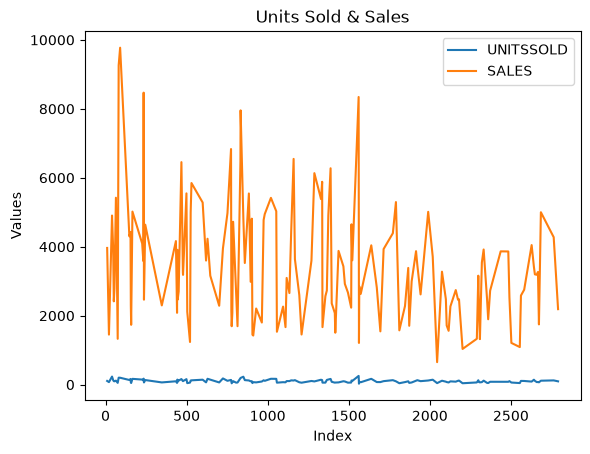

              UNITSSOLD
10   107.16216216216216
21                72.55
40   233.57142857142858
47   131.46666666666667
51   100.66666666666667
...                 ...
2667               76.0
2673   67.1923076923077
2685  113.6590909090909
2764              122.2
2791  95.17391304347827

[147 rows x 1 columns]


In [21]:
#Q13.
dataNAN['SALES'] = dataNAN['SALES'].astype(int)
dataNAN["UNITSSOLD"] = dataNAN["SALES"] / dataNAN["QUANTITYORDERED"]
sold = dataNAN[["UNITSSOLD","SALES"]]
sold.plot()
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Units Sold & Sales')
plt.show()
print(dataNAN[['UNITSSOLD']])